In [1]:
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from pyproj import Transformer
import colorcet as cc
import colormaps as colormaps
import matplotlib.gridspec as gridspec

## Load Data

In [2]:
data_dir = "/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/tracking/"
data_file = f"{data_dir}cloudid_20200613_002000.nc"

figdir = "/global/cfs/cdirs/m1657/zfeng/SCREAMv1-cess2/cell_conus/figures/"

print(data_file)

/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/tracking/cloudid_20200613_002000.nc


In [3]:
ds = xr.open_dataset(data_file).squeeze()
ds

<xarray.Dataset> Size: 206MB
Dimensions:             (lat: 1059, lon: 1799, features: 522)
Coordinates:
    time                datetime64[ns] 8B 2020-06-13T00:20:00
  * lon                 (lon) float64 14kB 237.3 237.3 237.3 ... 287.7 287.7
  * lat                 (lat) float64 8kB 21.14 21.16 21.19 ... 47.81 47.84
  * features            (features) int64 4kB 1 2 3 4 5 6 ... 518 519 520 521 522
Data variables: (12/24)
    radar_longitude     int64 8B ...
    radar_latitude      int64 8B ...
    base_time           datetime64[ns] 8B ...
    longitude           (lat, lon) float64 15MB ...
    latitude            (lat, lon) float64 15MB ...
    x                   (lon) int64 14kB ...
    ...                  ...
    feature_number      (lat, lon) float64 15MB ...
    nfeatures           int64 8B ...
    npix_feature        (features) int64 4kB ...
    refl_bkg            (lat, lon) float64 15MB ...
    peakedness          (lat, lon) float64 15MB ...
    core_steiner_orig   (lat, lon) int64 15MB ...
Attributes: (12/22)
    Title:                Cloudid file from 2020-06-13 00:20 UTC
    Contact:              Zhe Feng, zhe.feng@pnnl.gov
    Institution:          Pacific Northwest National Laboratory
    Created_on:           Fri Jan 30 00:22:40 2026
    Input_File:           /pscratch/sd/w/wcmca1/SCREAMv1-cess2/remap_conus_5m...
    dx:                   3000
    ...                   ...
    weakEchoThres:        15
    bkgrndRadius:         13.5
    min_corearea:         9.0
    echotop_gap:          1
    sfc_dz_min:           50
    sfc_dz_max:           1000.0

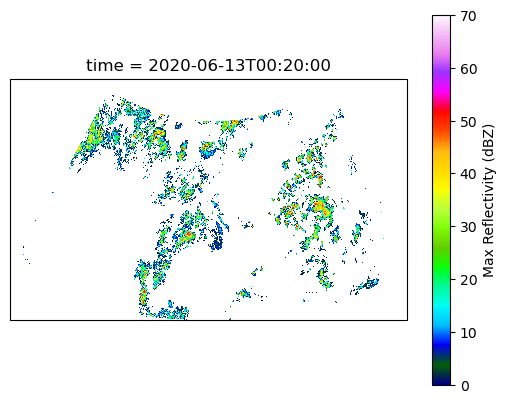

In [4]:
dbz_comp = ds.dbz_comp.where(ds.dbz_comp > 0, np.nan)
dbz_comp.plot(transform=ccrs.PlateCarree(), vmin=0, vmax=70, cmap='gist_ncar',
                subplot_kws=dict(projection=ccrs.LambertConformal()),
                cbar_kwargs=dict(label='Max Reflectivity (dBZ)'))

In [5]:
ds.convsf.attrs

{'long_name': 'Steiner Convective/Stratiform classification',
 'units': 'unitless',
 'comment': 'NAN:0, NO_SURF_ECHO:1, WEAK_ECHO:2, STRATIFORM:3, CONVECTIVE:4'}

In [6]:
ds.longitude.min()

<xarray.DataArray 'longitude' ()> Size: 8B
array(225.90452027)
Coordinates:
    time     datetime64[ns] 8B 2020-06-13T00:20:00

## Define function for 2x2 panel plots with LambertConformal projection

In [10]:
def plot_mxn_panels_lambert(nrow, ncol, data_arrays, lon_2d, lat_2d, cmaps, levels, 
                             titles=None, cbar_labels=None, figsize=(15, 10), 
                             dpi=150, map_extent=None, suptitle=None,
                             wspace=0.15, hspace=0.25, fontsize=12, figname=None):
    """
    Create a m×n panel plot with LambertConformal projection for eastern US.
    
    Parameters:
    -----------
    nrow : int
        Number of rows
    ncol : int
        Number of columns
    data_arrays : list of lists (nrow × ncol)
        Nested list containing 2D data arrays to plot. Can contain None for empty panels.
    lon_2d : 2D array
        Longitude coordinates
    lat_2d : 2D array
        Latitude coordinates
    cmaps : list of lists (nrow × ncol)
        Nested list of colormap names for each panel
    levels : list of lists (nrow × ncol)
        Nested list of (vmin, vmax) tuples for each panel
    titles : list of lists (nrow × ncol), optional
        Nested list of titles for each panel
    cbar_labels : list of lists (nrow × ncol), optional
        Nested list of colorbar labels for each panel
    figsize : tuple, optional
        Figure size (width, height)
    dpi : int, optional
        Figure resolution
    map_extent : tuple, optional
        Map extent as (lon_min, lon_max, lat_min, lat_max). Default: [-110, -75, 25, 50]
    suptitle : string, optional
        Suptitle for figure
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    fontsize : int, optional
        Base font size for labels
    figname : string, optional
        Name of the figure to save.
    
    Returns:
    --------
    fig : matplotlib figure
    axes : list of lists (nrow × ncol) of axes
    """
    mpl.rcParams['font.size'] = fontsize
    
    # Set map extent
    if map_extent is None:
        map_extent = [-110, -75, 25, 50]
    
    # Calculate central longitude
    central_lon = (map_extent[0] + map_extent[1]) / 2
    
    # Create projection
    proj = ccrs.LambertConformal(central_longitude=central_lon)
    
    # Set default titles and labels if not provided
    if titles is None:
        titles = [[f'Panel {i*ncol + j + 1}' for j in range(ncol)] for i in range(nrow)]
    if cbar_labels is None:
        cbar_labels = [['' for j in range(ncol)] for i in range(nrow)]
    
    # Create figure and GridSpec
    fig = plt.figure(figsize=figsize, dpi=dpi)
    
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, 
                          height_ratios=h_ratios, width_ratios=w_ratios, 
                          wspace=wspace, hspace=hspace)
    
    # Create axes for each panel
    axes = [[None for j in range(ncol)] for i in range(nrow)]
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if data is provided for this panel
            if data_arrays[row][col] is not None:
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(
                    1, 2, subplot_spec=gs[row, col], 
                    height_ratios=[1], width_ratios=[1, 0.04], 
                    wspace=0.02, hspace=0.
                )
                
                # Create axis with projection
                ax = plt.subplot(gss[0], projection=proj)
                
                # Set extent
                ax.set_extent(map_extent, crs=ccrs.PlateCarree())
                
                # Add map features
                ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
                ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
                ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                ax.set_aspect('auto', adjustable=None)
                
                # Plot data
                vmin, vmax = levels[row][col]
                im = ax.pcolormesh(lon_2d, lat_2d, data_arrays[row][col], 
                                  transform=ccrs.PlateCarree(),
                                  cmap=cmaps[row][col], vmin=vmin, vmax=vmax,
                                  shading='auto')
                
                # Add title
                ax.set_title(titles[row][col], loc='left', fontsize=fontsize, fontweight='bold')
                
                # Add gridlines without labels inside the map
                gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', 
                                alpha=0.5, linestyle='--')
                
                # Add axis labels only on outer edges
                if row == nrow - 1:  # Bottom row
                    ax.set_xlabel('Longitude', fontsize=fontsize-2)
                if col == 0:  # Left column
                    ax.set_ylabel('Latitude', fontsize=fontsize-2)
                
                # Create colorbar axis
                cax = plt.subplot(gss[1])
                cbar = plt.colorbar(im, cax=cax, label=cbar_labels[row][col])
                
                axes[row][col] = ax
    
    # Figure title
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize*1.5, fontweight='bold')

    # if figname is not None:
    #     fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')

    return fig, axes

## Example usage with sample data

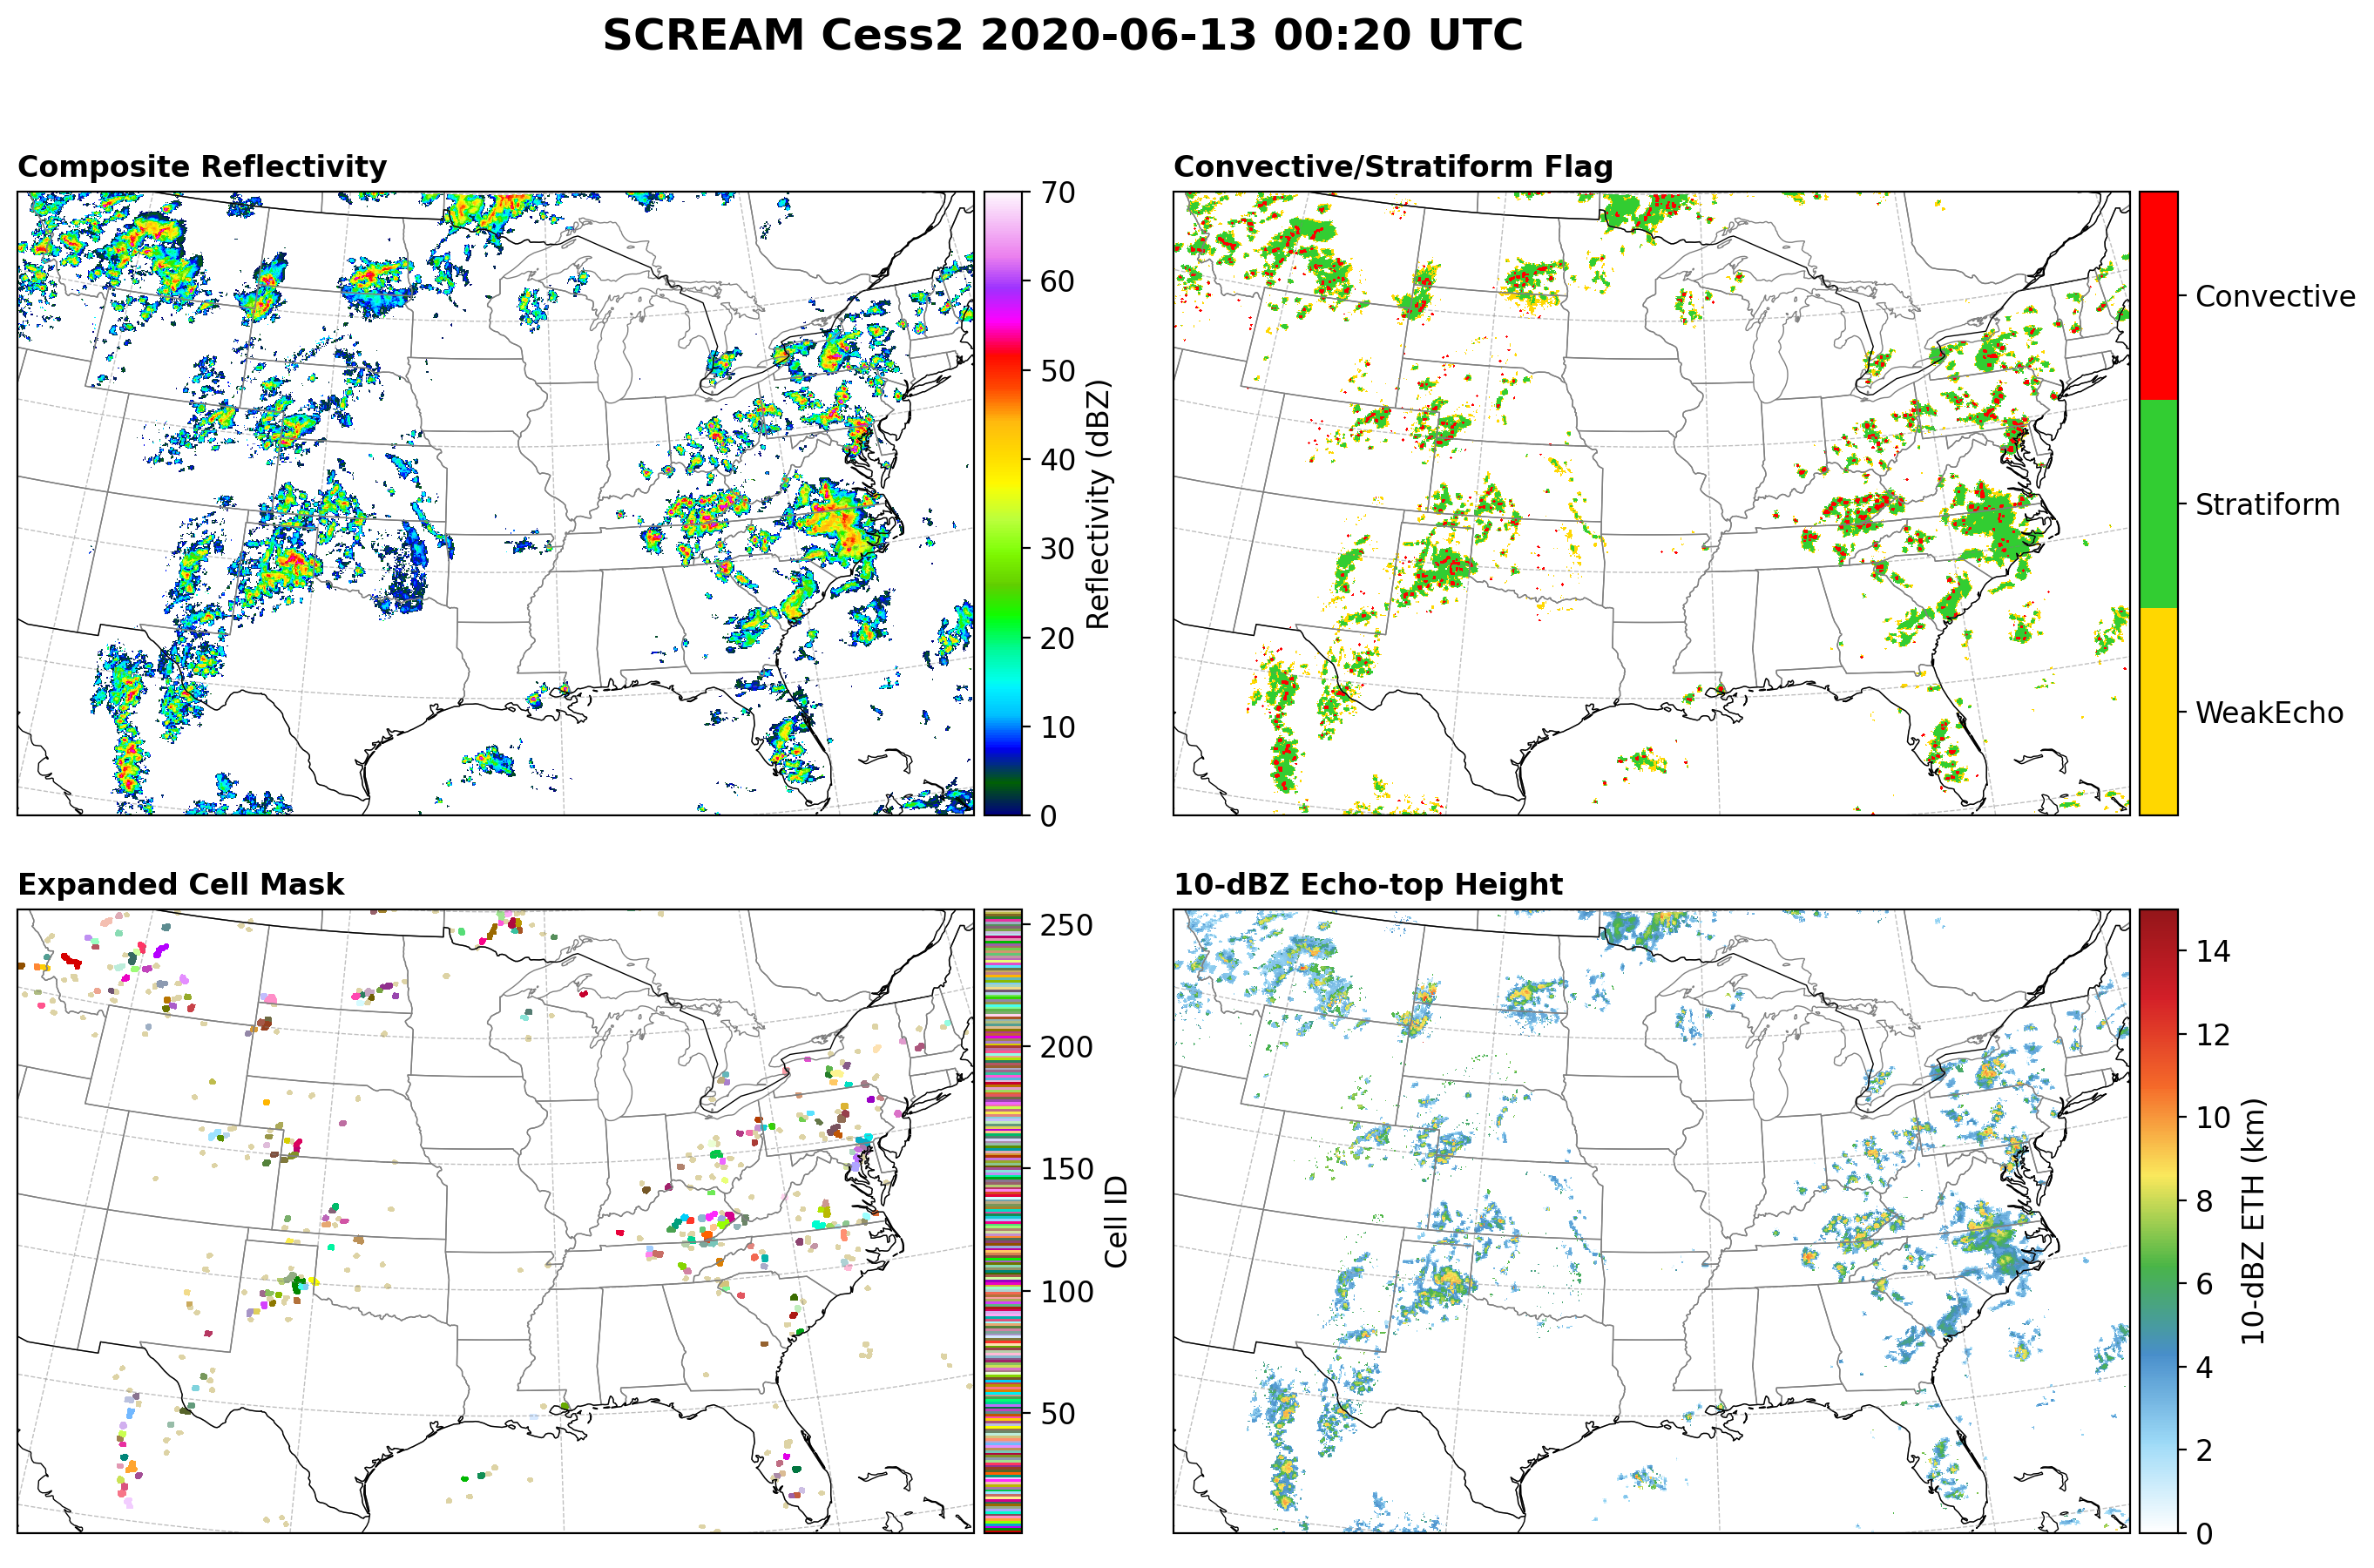

/global/cfs/cdirs/m1657/zfeng/SCREAMv1-cess2/cell_conus/figures/cellmask_4panels_20200613_0020.png


In [12]:
# Prepare data arrays (assuming you have these variables from cell tracking)
# Example: composite reflectivity, Steiner classification, convective core, expanded core
# For this example, we'll use the available data and create sample masks
map_extent = [-110, -75, 25, 49]

# Get lon/lat coordinates
lon_2d = ds.longitude.values
lat_2d = ds.latitude.values

# Prepare 4 data arrays (as nested list for 2x2 layout)
data1 = ds.dbz_comp.where(ds.dbz_comp > 0, np.nan)  # Composite reflectivity
data2 = ds.convsf.where(ds.convsf > 1, np.nan)  # Convective/stratiform flag
data3 = ds.conv_mask_inflated.where(ds.conv_mask_inflated > 0, np.nan)  # expanded convective cell mask
data4 = ds.echotop10 / 1000  # 10dBZ ETH [m to km]

# Create custom colormap for convective/stratiform classification

# Define colors for categories 2, 3, 4 (NO_SURF_ECHO:1 is masked)
convsf_colors = ['gold', 'limegreen', 'red']
convsf_cmap = ListedColormap(convsf_colors)
convsf_bounds = [1.5, 2.5, 3.5, 4.5]  # Boundaries between categories
convsf_norm = BoundaryNorm(convsf_bounds, convsf_cmap.N)

# Organize data as nested list [row][col]
data_arrays = [
    [data1, data2],  # First row
    [data3, data4]   # Second row
]

# Define colormaps (following test_idcell_reflectivity.ipynb)
cmaps = [
    ['gist_ncar', convsf_cmap],  # First row - use custom cmap for data2
    [colormaps.cet_g_bw_minc_minl, colormaps.WhiteBlueGreenYellowRed]  # Second row
]

# Define levels (vmin, vmax) for each panel
levels = [
    [(0, 70), (1.5, 4.5)],    # First row - adjusted range for categorical data
    [(1, 256), (0, 15)]   # Second row
]

# Define titles
titles = [
    ['Composite Reflectivity', 'Convective/Stratiform Flag'],
    ['Expanded Cell Mask', '10-dBZ Echo-top Height']
]

# Define colorbar labels
cbar_labels = [
    ['Reflectivity (dBZ)', ''],
    ['Cell ID', '10-dBZ ETH (km)']
]

# Suptitle
time_str = ds.time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str_fig = ds.time.dt.strftime('%Y%m%d_%H%M').item()
suptitle = f"SCREAM Cess2 {time_str}"
figname = f"{figdir}cellmask_4panels_{time_str_fig}.png"

# Create the plot
fig, axes = plot_mxn_panels_lambert(
    nrow=2, ncol=2,
    data_arrays=data_arrays,
    lon_2d=lon_2d,
    lat_2d=lat_2d,
    cmaps=cmaps,
    levels=levels,
    titles=titles,
    suptitle=suptitle,
    cbar_labels=cbar_labels,
    figsize=(16, 10),
    dpi=200,
    map_extent=map_extent,
    wspace=0.15, hspace=0.15,
    fontsize=12,
    figname=figname,
)

# Customize colorbar for convective/stratiform panel (row=0, col=1)
# Find all axes in the figure and identify the colorbar axis for the second panel
all_axes = fig.get_axes()
# The colorbar axis is the one right after the map axis for panel [0,1]
# Axes are created in order: map[0,0], cbar[0,0], map[0,1], cbar[0,1], map[1,0], cbar[1,0], map[1,1], cbar[1,1]
# So colorbar for panel [0,1] should be at index 3 (0-indexed: 0,1,2,3)
cbar_ax = all_axes[3]  # Colorbar axis for second panel (row=0, col=1)
# Set ticks and labels directly on the colorbar axis
cbar_ax.set_yticks([2, 3, 4])
cbar_ax.set_yticklabels(['WeakEcho', 'Stratiform', 'Convective'])

plt.show()

if figname is not None:
    fig.savefig(figname, dpi=200, bbox_inches='tight', facecolor='w')

print(figname)

In [9]:
time_str

'2020-06-13 00:20 UTC'